In [ ]:
import scipy.optimize as so
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import sys
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

In [2]:
# Define plotting assistants 
# List of default colors
color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Plot parameters and sizes
plt.rc('font', size = 16)
plt.rc('axes', linewidth=1, titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)    # fontsize of the x and y labels
plt.rc('xtick', top=True, bottom=True, direction='in')
plt.rc('ytick', left=True, right=True, direction='in') 
plt.rc('figure', titlesize=5)
plt.rc('legend', fontsize=14)
plt.rc('lines', linewidth=2)

In [3]:
# Read in the simulation data
data = pd.read_csv("tj.dat", sep=r'\s+')

In [4]:
# Reduce the window of current and time to be used for fitting
start_index = 155
end_index = -1 #849
time = data['t'].iloc[start_index:end_index].values
current = data['Jext'].iloc[start_index:end_index].values
current_error = data['errJ'].iloc[start_index:end_index].values
current_upper_lim = current + current_error
current_lower_lim = current - current_error

[]

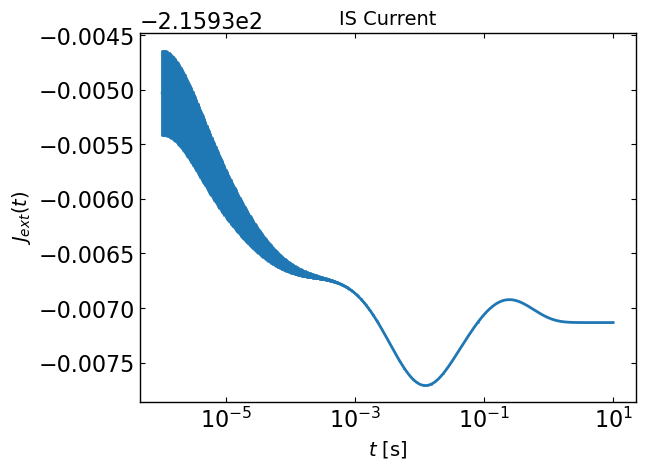

In [5]:
# Plot the Current
plt.errorbar(time, current, yerr=current_error)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$')
plt.title("IS Current")
plt.plot()

In [6]:
# Calculate the cost betwen the central curve and the curves +- error to get an experimental error threshold 
cost_threshold = (1/2)*np.square(current_error).sum()
current_cost = (1/2)*np.square(current_error)
print(f"Cost Threshold: {cost_threshold:.3}")

Cost Threshold: 7.12e-06


In [7]:
# Apply scaling to the current 
scaled_current = (current - current.min())/(current.max()-current.min())
scaled_cost_threshold = cost_threshold/(current.max()-current.min())**2
scaled_current_error = current_error/(current.max()-current.min())**2
scaled_current_cost = current_cost/(current.max()-current.min())**2

In [8]:
print(f"Len current: {len(scaled_current)}")
print(f"Len error: {len(current_error)}")

Len current: 811
Len error: 811


In [9]:
# Find the DRT fits for m=1,...,10
# Set the values for intial guesses that don't depend on m
polarity = 1 if time[-1] < time[0] else -1
offset0 = scaled_current.max() if polarity == 1 else scaled_current.min()

# Set iteration variables
m_values = range(1,11)
fits = []

for m in m_values:
    # Set the initial guesses for parameters that do depend on m
    U0 = np.ones(m)/m
    tau0 = np.geomspace(time[0], time[-1], m)

    # Apply the fit
    fit = drt.fit_DRT_curve(time, scaled_current, U0, tau0, offset0=offset0) 

    # Add to collection of fits
    fits.append(fit)

/home/josh-edmundson/Documents/SIMsalabim-installs/pySIMsalabim/Notebooks/Projects/Den RT/DRT IS Impedance Behaviour in Spectrum/../../../../pySIMsalabim/aux_funcs/time_domain_DRT.py:92: RuntimeWarning: overflow encountered in exp
  calculated_DRT_curve = (U @ np.exp(-np.outer(1/tau, t))) + offset


[]

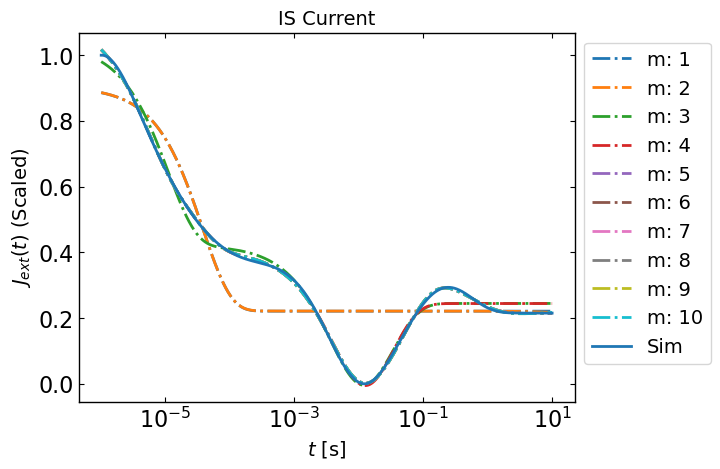

In [11]:
# Plot all the fits to make sure they make physical sense
for fit in fits: 
    plt.plot(time, fit.DRT_curve, label=f"m: {fit.m}", linestyle="-.")

plt.plot(time, scaled_current, label='Sim')
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$ (Scaled)')
plt.title("IS Current")
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.plot()

[]

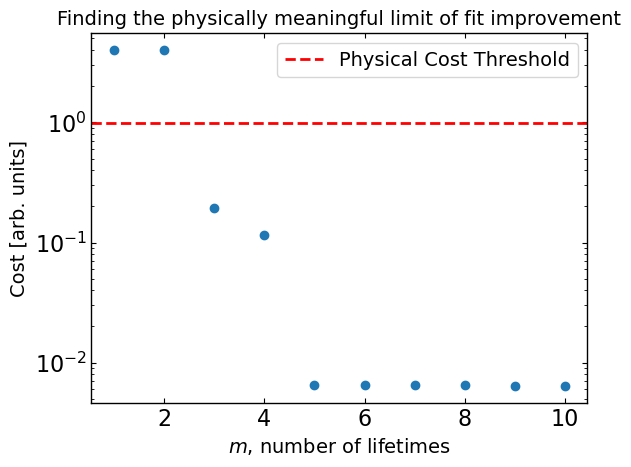

In [98]:
m_and_scaled_costs = np.array([[fit.m, fit.cost] for fit in fits])

plt.scatter(m_and_scaled_costs[:, 0], m_and_scaled_costs[:, 1])
plt.axhline(scaled_cost_threshold, linestyle='--', label='Physical Cost Threshold', color='red')
plt.xlabel('$m$, number of lifetimes')
plt.ylabel('Cost [arb. units]')
plt.yscale('log')
plt.title("Finding the physically meaningful limit of fit improvement")
plt.legend()
plt.plot()

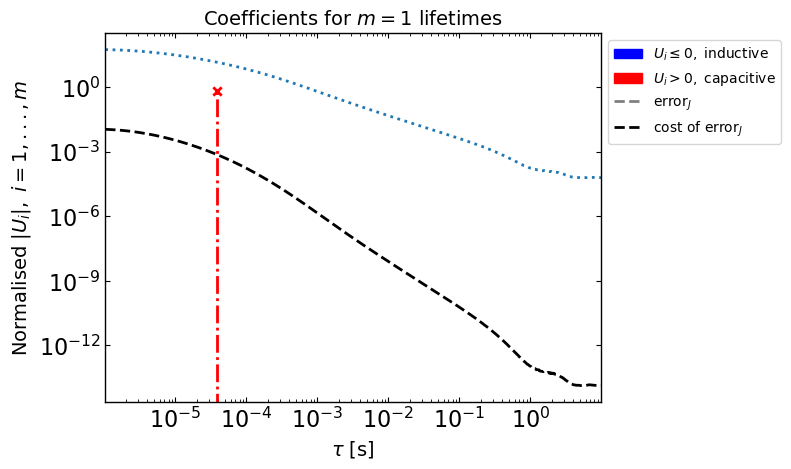

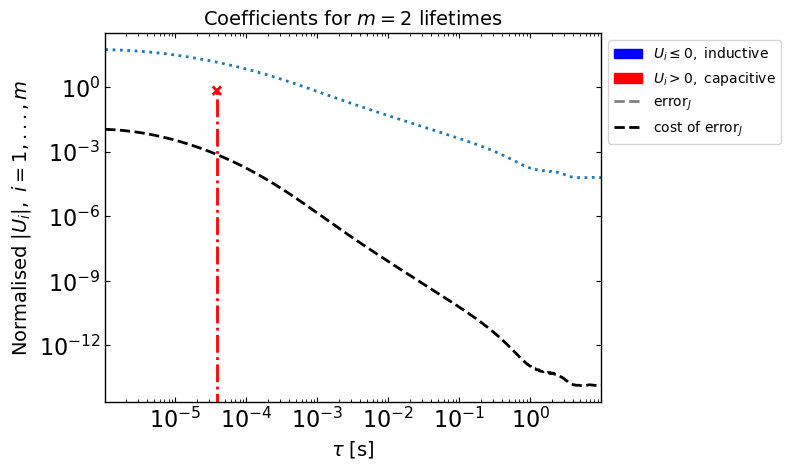

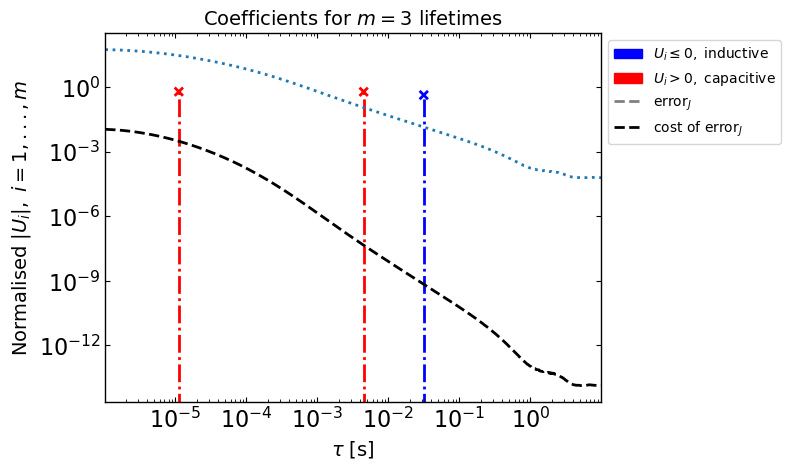

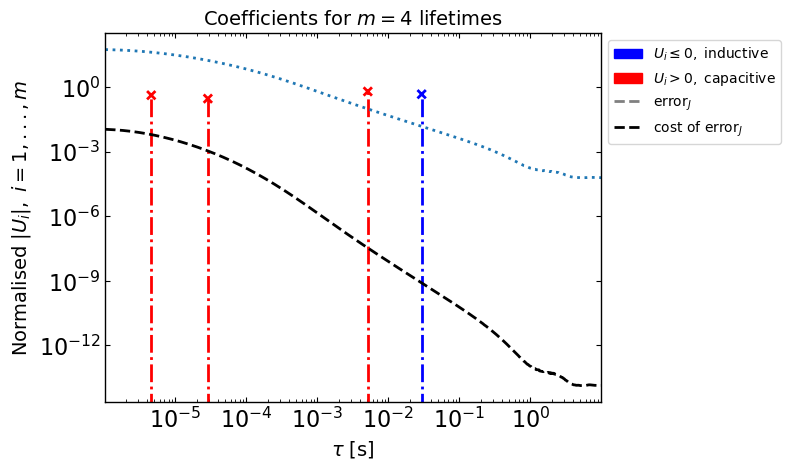

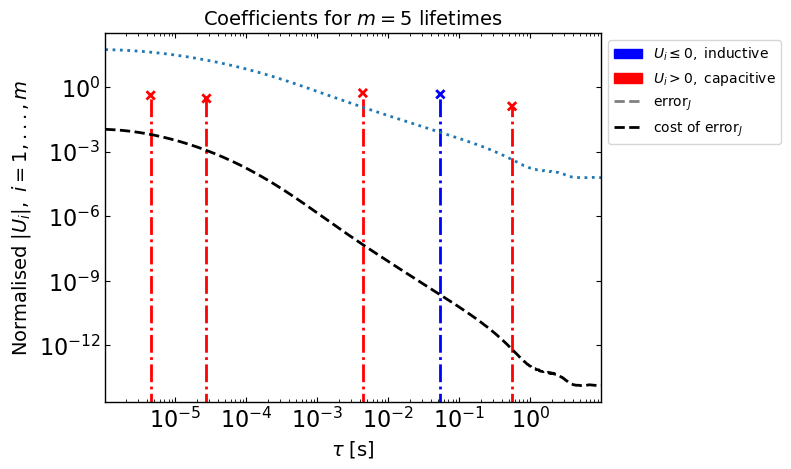

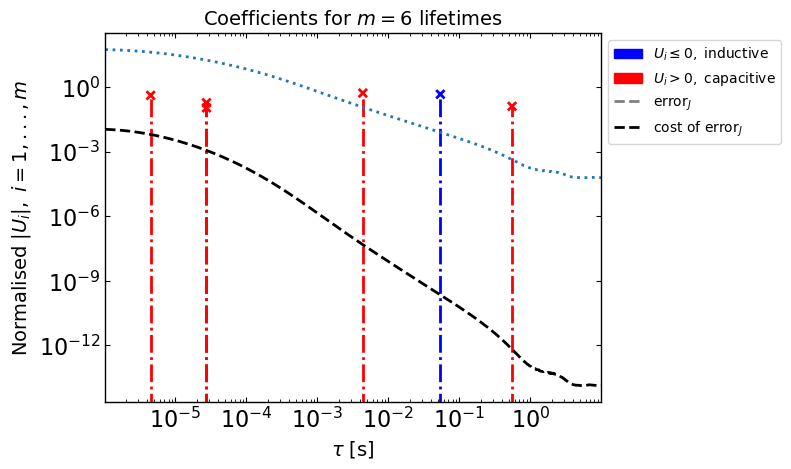

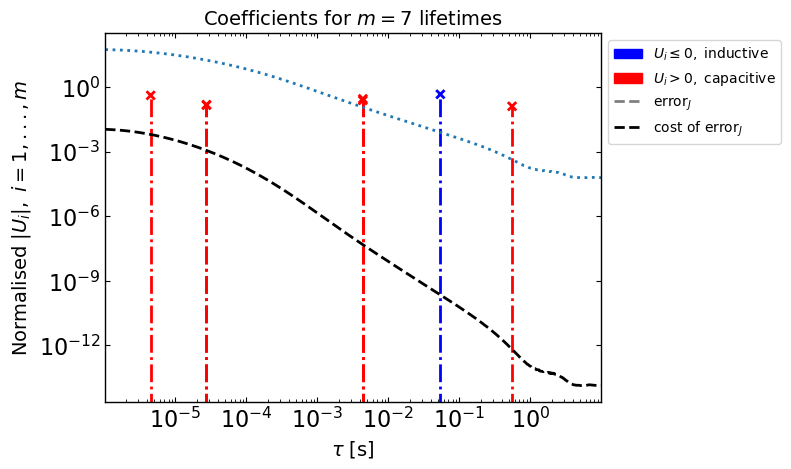

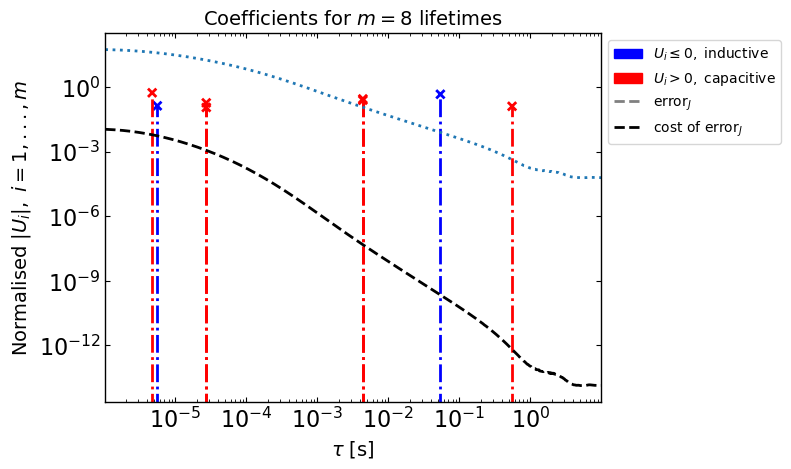

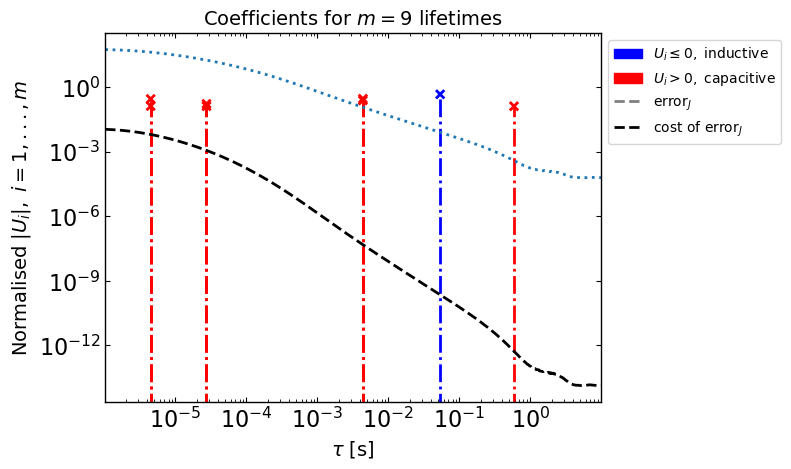

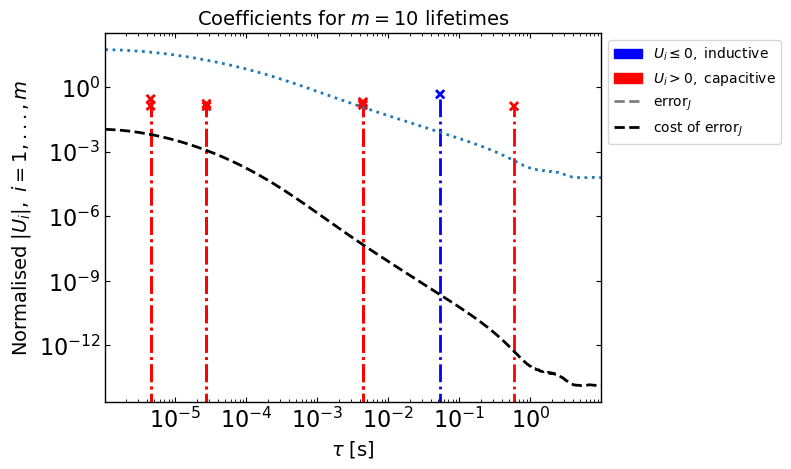

In [99]:
import matplotlib.patches as patches
import matplotlib.lines as mlines
# Plot |U| against t for each m 
xlim = [time[0], time[-1]]
blue_patch = patches.Patch(color='blue', label='$U_i \\leq 0,$ inductive')
red_patch = patches.Patch(color='red', label='$U_i > 0, $ capacitive')
black_line = mlines.Line2D([], [], color='black', linestyle='--', label='$\\text{cost of error}_J$')
grey_line = mlines.Line2D([], [], color='grey', linestyle='--', label='$\\text{error}_J$')

# blue_line = mlines.Line2D([], [], color='blue', linestyle='-.', marker='x', markersize=8, label='$U_i \\leq 0$')
# red_line = mlines.Line2D([], [], color='red', linestyle='-.', marker='x', markersize=8, label='$U_i > 0$')

for fit in fits:
    polarity = fit.U > 0
    colour_map = list(map(str, np.where(polarity, 'r', 'b')))
    marker_map = list(map(str, np.where(polarity, 'x', 'v')))
    plt.vlines(fit.tau, ymin=0, ymax=np.abs(fit.U), colors=colour_map, linestyles='-.')
    plt.scatter(fit.tau, np.abs(fit.U), c=colour_map, marker='x')
    plt.plot(time, scaled_current_cost, color='black', linestyle='--')
    plt.plot(time, scaled_current_error, label='grey', linestyle=':')
    plt.xlim(xlim)
    plt.xlabel("$\\tau$ [s]")
    plt.ylabel(f"Normalised $|U_i|,$ $i = 1, ..., m$")
    plt.xscale("log")
    plt.yscale("log")
    plt.title(f"Coefficients for $m=${fit.m} lifetimes")
    plt.legend(handles =[blue_patch, red_patch, grey_line, black_line], prop={'size': 10}, bbox_to_anchor=(1,1), loc="upper left")
    plt.show()

In [100]:
fits[2].tau

array([1.11682705e-05, 4.48296329e-03, 3.15014282e-02])